# Root inspector

Inspect .root files and its branches and leaves and such. Create plots that visualize the experiement shows hits in ECal in 2D and 3D plots. Inspects ancestry labels that are stored in branches. 

Hans Alin gjorde fina plots i 2D plots ECal RecHits och de var inspiration till detta. 

**Tips!** Om man vill navigera sig i events.root-filer med ROOT-programmet (tips från Lene-Kristian)

denv rootbrowse runs/it_pileup/events.root

## Importera och välj typ av events-fil (output från it_pileup/xxx.py)

Alternativ: 

ecal_pn.root

pileup.root

events.root


Inspektera filen och se vilka unika branches, leaves osv som finns i uproot trädet och utgå från det i resten av denna fil som inspekterar .root filer.

In [51]:
print("hello")

hello


In [52]:
import uproot
import matplotlib.pyplot as plt
import awkward as ak

events_path = "../runs/it_pileup/events.root"
figures_path = "figures/"

file = uproot.open(events_path)
tree = file["LDMX_Events"]
tree_keys = set(tree.keys())

overlay_tree = "EcalRecHits_overlay/EcalRecHits_overlay.energy_" in tree_keys
pileup_tree = "EcalSimHits_pileup/EcalSimHits_pileup.edep_" in tree_keys
ecal_pn_tree = "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn.edep_" in tree_keys

if overlay_tree:
    ecal_hit_label = "RecHits"
    ecal_x_branch = "EcalRecHits_overlay/EcalRecHits_overlay.xpos_"
    ecal_y_branch = "EcalRecHits_overlay/EcalRecHits_overlay.ypos_"
    ecal_z_branch = "EcalRecHits_overlay/EcalRecHits_overlay.zpos_"
    ecal_energy_branch = "EcalRecHits_overlay/EcalRecHits_overlay.energy_"
elif pileup_tree:
    ecal_hit_label = "SimHits"
    ecal_x_branch = "EcalSimHits_pileup/EcalSimHits_pileup.x_"
    ecal_y_branch = "EcalSimHits_pileup/EcalSimHits_pileup.y_"
    ecal_z_branch = "EcalSimHits_pileup/EcalSimHits_pileup.z_"
    ecal_energy_branch = "EcalSimHits_pileup/EcalSimHits_pileup.edep_"
elif ecal_pn_tree:
    ecal_hit_label = "SimHits"
    ecal_x_branch = "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn.x_"
    ecal_y_branch = "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn.y_"
    ecal_z_branch = "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn.z_"
    ecal_energy_branch = "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn.edep_"
else:
    raise KeyError("Could not find a supported ECal branch layout in this ROOT file.")

keys = [k.split(";")[0] for k in file.keys()]          # strip ROOT cycle suffix ";1"
keys = sorted(set(keys))

print(f"Found {len(keys)} unique objects in {events_path}\n")
for k in keys:
    print(k)

print("\nBRANCHES:")
for b in tree.keys():
    print(b)

print(f"\nDetected ECal layout: {ecal_hit_label}")

Found 2 unique objects in ../runs/it_pileup/events.root

LDMX_Events
LDMX_Run

BRANCHES:
EventHeader
EventHeader/event_number_
EventHeader/run_
EventHeader/timestamp_
EventHeader/timestamp_/timestamp_.fSec
EventHeader/timestamp_/timestamp_.fNanoSec
EventHeader/weight_
EventHeader/is_real_data_
EventHeader/int_parameters_
EventHeader/int_parameters_/int_parameters_.first
EventHeader/int_parameters_/int_parameters_.second
EventHeader/float_parameters_
EventHeader/float_parameters_/float_parameters_.first
EventHeader/float_parameters_/float_parameters_.second
EventHeader/string_parameters_
EventHeader/string_parameters_/string_parameters_.first
EventHeader/string_parameters_/string_parameters_.second
SimParticles_ecal_pn
SimParticles_ecal_pn/SimParticles_ecal_pn.first
SimParticles_ecal_pn/SimParticles_ecal_pn.second.energy_
SimParticles_ecal_pn/SimParticles_ecal_pn.second.pdg_id_
SimParticles_ecal_pn/SimParticles_ecal_pn.second.gen_status_
SimParticles_ecal_pn/SimParticles_ecal_pn.second.

## Inspect ECal hit metadata and output a table

Here one can inspect track_id and origin_id for specific hits. origin_id encodes ancestry information and is found in the contrib branch.

In [53]:
import awkward as ak
import numpy as np
import pandas as pd

event_idx = 0

# Three different cases...
if overlay_tree and "EcalSimHitsOverlay_overlay/EcalSimHitsOverlay_overlay.id_" in tree_keys:
    simhit_prefix = "EcalSimHitsOverlay_overlay/EcalSimHitsOverlay_overlay"
elif "EcalSimHits_pileup/EcalSimHits_pileup.id_" in tree_keys:
    simhit_prefix = "EcalSimHits_pileup/EcalSimHits_pileup"
elif "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn.id_" in tree_keys:
    simhit_prefix = "EcalSimHits_ecal_pn/EcalSimHits_ecal_pn"
else:
    raise KeyError("Could not find a supported ECal sim-hit collection in this ROOT file.")

# These are named the same in all three cases
branches = [
    f"{simhit_prefix}.id_",
    f"{simhit_prefix}.edep_",
    f"{simhit_prefix}.x_",
    f"{simhit_prefix}.y_",
    f"{simhit_prefix}.z_",
]

optional_suffixes = [
    "n_contribs_",
    "track_id_contribs_",
    "origin_contribs_",
    "edep_contribs_",
    "pdg_code_contribs_",
]
for suffix in optional_suffixes:
    branch_name = f"{simhit_prefix}.{suffix}"
    if branch_name in tree_keys:
        branches.append(branch_name)

arrs = tree.arrays(branches)

ids  = arrs[f"{simhit_prefix}.id_"][event_idx]
edep = arrs[f"{simhit_prefix}.edep_"][event_idx]
x    = arrs[f"{simhit_prefix}.x_"][event_idx]
y    = arrs[f"{simhit_prefix}.y_"][event_idx]
z    = arrs[f"{simhit_prefix}.z_"][event_idx]

has_contrib_info = f"{simhit_prefix}.n_contribs_" in arrs.fields
if has_contrib_info:
    ncontrib  = arrs[f"{simhit_prefix}.n_contribs_"][event_idx]
    track_ids = arrs[f"{simhit_prefix}.track_id_contribs_"][event_idx]
    origins   = arrs[f"{simhit_prefix}.origin_contribs_"][event_idx]
    edep_c    = arrs[f"{simhit_prefix}.edep_contribs_"][event_idx]
    pdg_c     = arrs[f"{simhit_prefix}.pdg_code_contribs_"][event_idx]

rows = []
for ihit in range(len(ids)):
    if has_contrib_info:
        n = int(ncontrib[ihit])
        if n == 0:
            rows.append({
                "hit_idx": ihit,
                "hit_id": int(ids[ihit]),
                "x": float(x[ihit]),
                "y": float(y[ihit]),
                "z": float(z[ihit]),
                "hit_edep": float(edep[ihit]),
                "n_contribs": 0,
                "dominant_track_id": -1,
                "dominant_origin": -1,
                "dominant_pdg": 0,
                "dominant_frac": np.nan,
                "is_mixed": False,
                "all_track_ids": [],
                "all_origins": [],
            })
            continue

        hit_track_ids = [int(v) for v in ak.to_list(track_ids[ihit])]
        hit_origins   = [int(v) for v in ak.to_list(origins[ihit])]
        hit_edep_c    = [float(v) for v in ak.to_list(edep_c[ihit])]
        hit_pdg_c     = [int(v) for v in ak.to_list(pdg_c[ihit])]

        dom = int(np.argmax(hit_edep_c))
        total_c = sum(hit_edep_c)
        distinct_tracks = set(hit_track_ids)

        rows.append({
            "hit_idx": ihit,
            "hit_id": int(ids[ihit]),
            "x": float(x[ihit]),
            "y": float(y[ihit]),
            "z": float(z[ihit]),
            "hit_edep": float(edep[ihit]),
            "n_contribs": n,
            "dominant_track_id": hit_track_ids[dom],
            "dominant_origin": hit_origins[dom],
            "dominant_pdg": hit_pdg_c[dom],
            "dominant_frac": hit_edep_c[dom] / total_c if total_c > 0 else np.nan,
            "is_mixed": len(distinct_tracks) > 1, # BAD
            "all_track_ids": hit_track_ids,
            "all_origins": hit_origins,
        })
    else:
        rows.append({
            "hit_idx": ihit,
            "hit_id": int(ids[ihit]),
            "x": float(x[ihit]),
            "y": float(y[ihit]),
            "z": float(z[ihit]),
            "hit_edep": float(edep[ihit]),
            "n_contribs": 1,
            "dominant_track_id": -1,
            "dominant_origin": -1,
            "dominant_pdg": 0,
            "dominant_frac": np.nan,
            "is_mixed": False,
            "all_track_ids": [],
            "all_origins": [],
        })

hits_df = pd.DataFrame(rows)
hits_df.head(20)

,hit_idx,hit_id,x,y,z,hit_edep,n_contribs,dominant_track_id,dominant_origin,dominant_pdg,dominant_frac,is_mixed,all_track_ids,all_origins
0,0,335544479,-13.682768,37.433102,247.632004,0.118365,1,134217729,1,11,1.000000,False,[134217729],[1]
1,1,335544503,-10.463355,26.405071,247.632004,0.161976,1,167772161,3,11,1.000000,False,[167772161],[3]
2,2,335544532,-4.914955,-23.951057,247.632004,0.155556,1,150994945,2,11,1.000000,False,[150994945],[2]
3,3,335544566,15.625290,81.335014,247.821838,0.666925,1,150997535,2,11,1.000000,False,[150997535],[2]
4,4,335675551,-13.943929,37.380547,256.212006,0.195952,1,134217729,1,11,1.000000,False,[134217729],[1]
5,5,335675552,-10.530673,26.417679,256.212006,0.117470,1,167772161,3,11,1.000000,False,[167772161],[3]
6,6,335675581,-5.016785,-24.012712,256.212006,0.216559,1,150994945,2,11,1.000000,False,[150994945],[2]
7,7,335675598,1.424706,26.156797,256.120483,0.517371,1,167780317,3,11,1.000000,False,[167780317],[3]
8,8,335806623,-14.580139,37.357330,273.476013,0.187586,1,134217729,1,11,1.000000,False,[134217729],[1]
9,9,335806645,-8.581753,37.983780,273.476013,0.257137,2,134217838,1,11,0.595984,True,"[134217839, 134217838]","[1, 1]"


### Ett exempel på hur en encoded track ID blir decoded

In [54]:
def decode_track_id(x):
    if x < 0:
        return None
    return {
        "raw": int(x),
        "version": (x >> 27) & 0xF,
        "event_index": (x >> 24) & 0x7,
        "track_id": x & ((1 << 24) - 1),
    }

print(decode_track_id(134217729))
print(decode_track_id(150994945))

# origin id
print(decode_track_id(134217729))          
print(decode_track_id(150994945))

{'raw': 134217729, 'version': 1, 'event_index': 0, 'track_id': 1}
{'raw': 150994945, 'version': 1, 'event_index': 1, 'track_id': 1}
{'raw': 134217729, 'version': 1, 'event_index': 0, 'track_id': 1}
{'raw': 150994945, 'version': 1, 'event_index': 1, 'track_id': 1}


Hitta EcalRecHits i x, y, z

Hitta energierna för de olika hits som finns och plotta i histogram

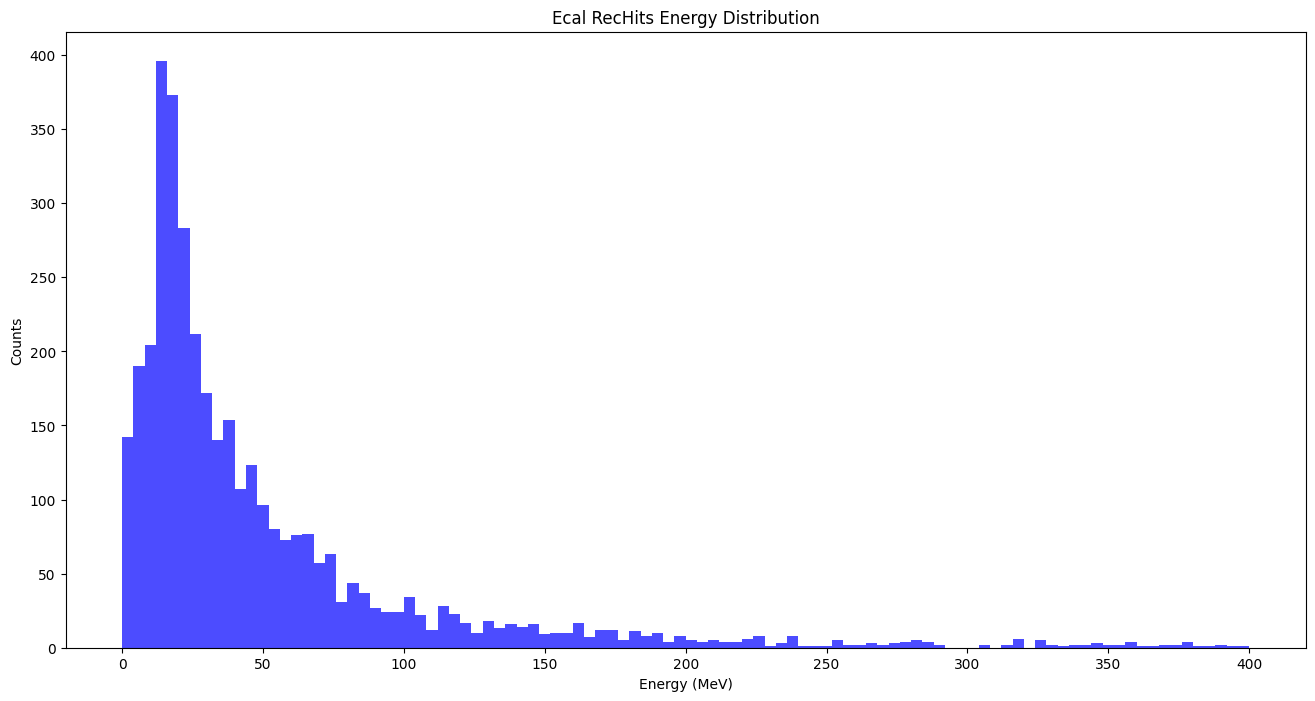

In [55]:
# To array x, y ,z and energy of the detected ECal hit collection
ecal_y = tree[ecal_y_branch].array()
ecal_x = tree[ecal_x_branch].array()
ecal_z = tree[ecal_z_branch].array()
ecal_energy = tree[ecal_energy_branch].array()

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax.hist(ak.flatten(ecal_energy), bins=100, alpha=0.7, color='blue', range=[0,400])
ax.set_title(f"Ecal {ecal_hit_label} Energy Distribution")
ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Counts")
plt.savefig(f"{figures_path}ecal_energy.png", dpi=300)
#plt.close()

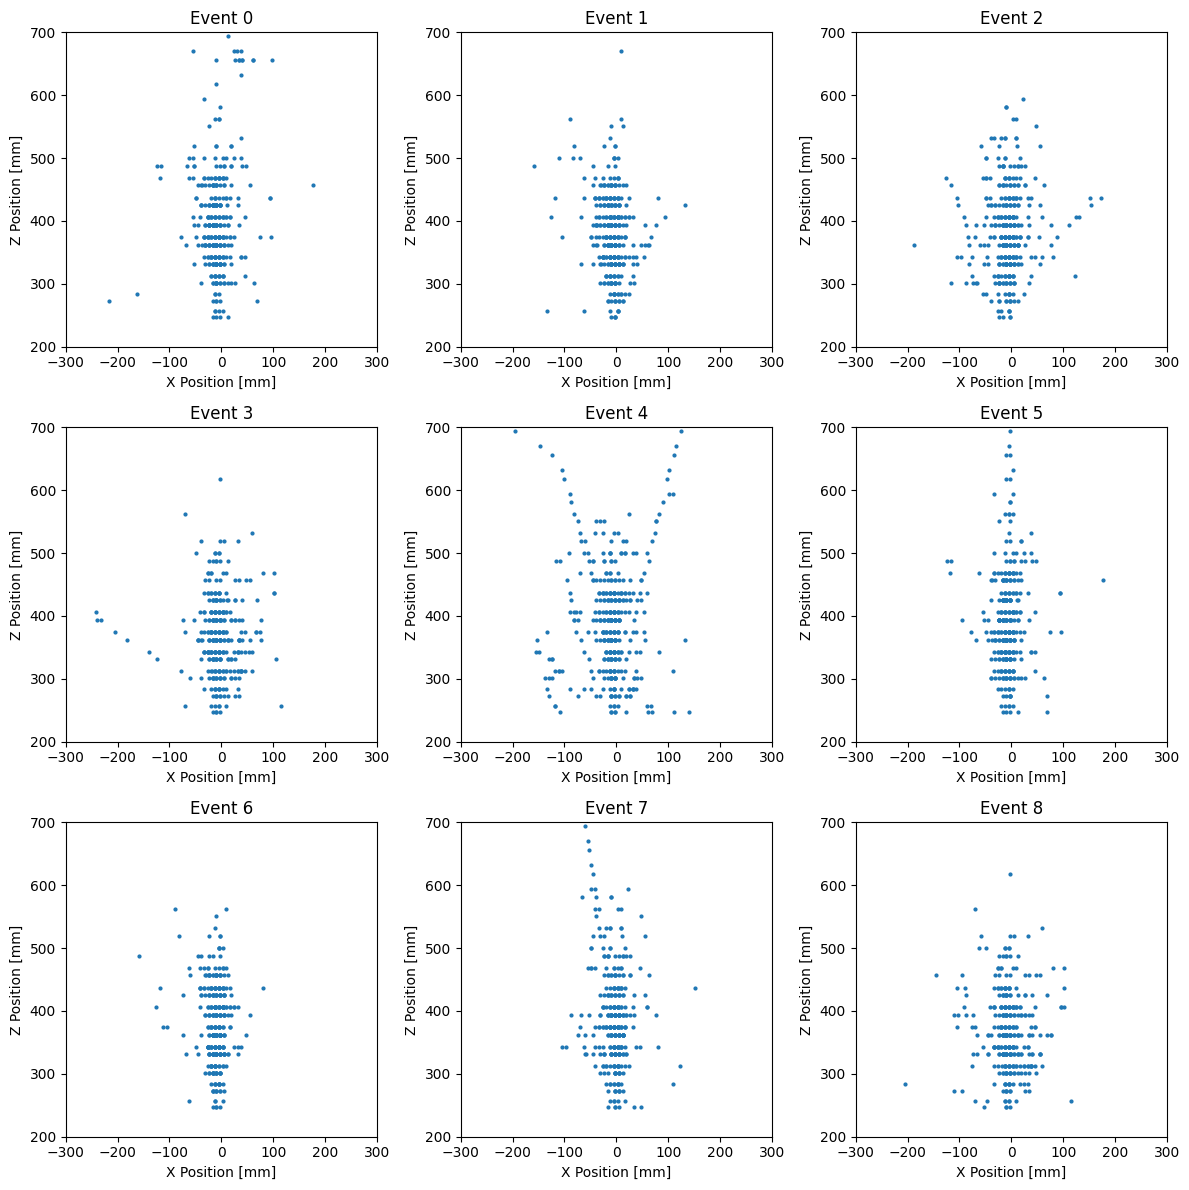

In [56]:
# Scatter plots of x vs z for up to first 9 events (3x3 grid)

rows, columns = 3, 3
nplots = rows * columns
nevents = len(ecal_x)
nshow = min(nplots, nevents)

fig, ax = plt.subplots(rows, columns, figsize=(12, 12))
ax = ax.flatten()

for index in range(nshow):
    ax[index].scatter(ecal_x[index], ecal_z[index], s=4)
    ax[index].set_title(f"Event {index}")
    ax[index].set_xlabel("X Position [mm]")
    ax[index].set_ylabel("Z Position [mm]")
    ax[index].set_xlim(-300, 300)
    ax[index].set_ylim(200, 700)

# turn off unused panels if fewer than 9 events
for index in range(nshow, nplots):
    ax[index].axis("off")

plt.tight_layout()
plt.savefig(f"{figures_path}ecal_x_z_hits_3x3.png", dpi=300)
plt.show()

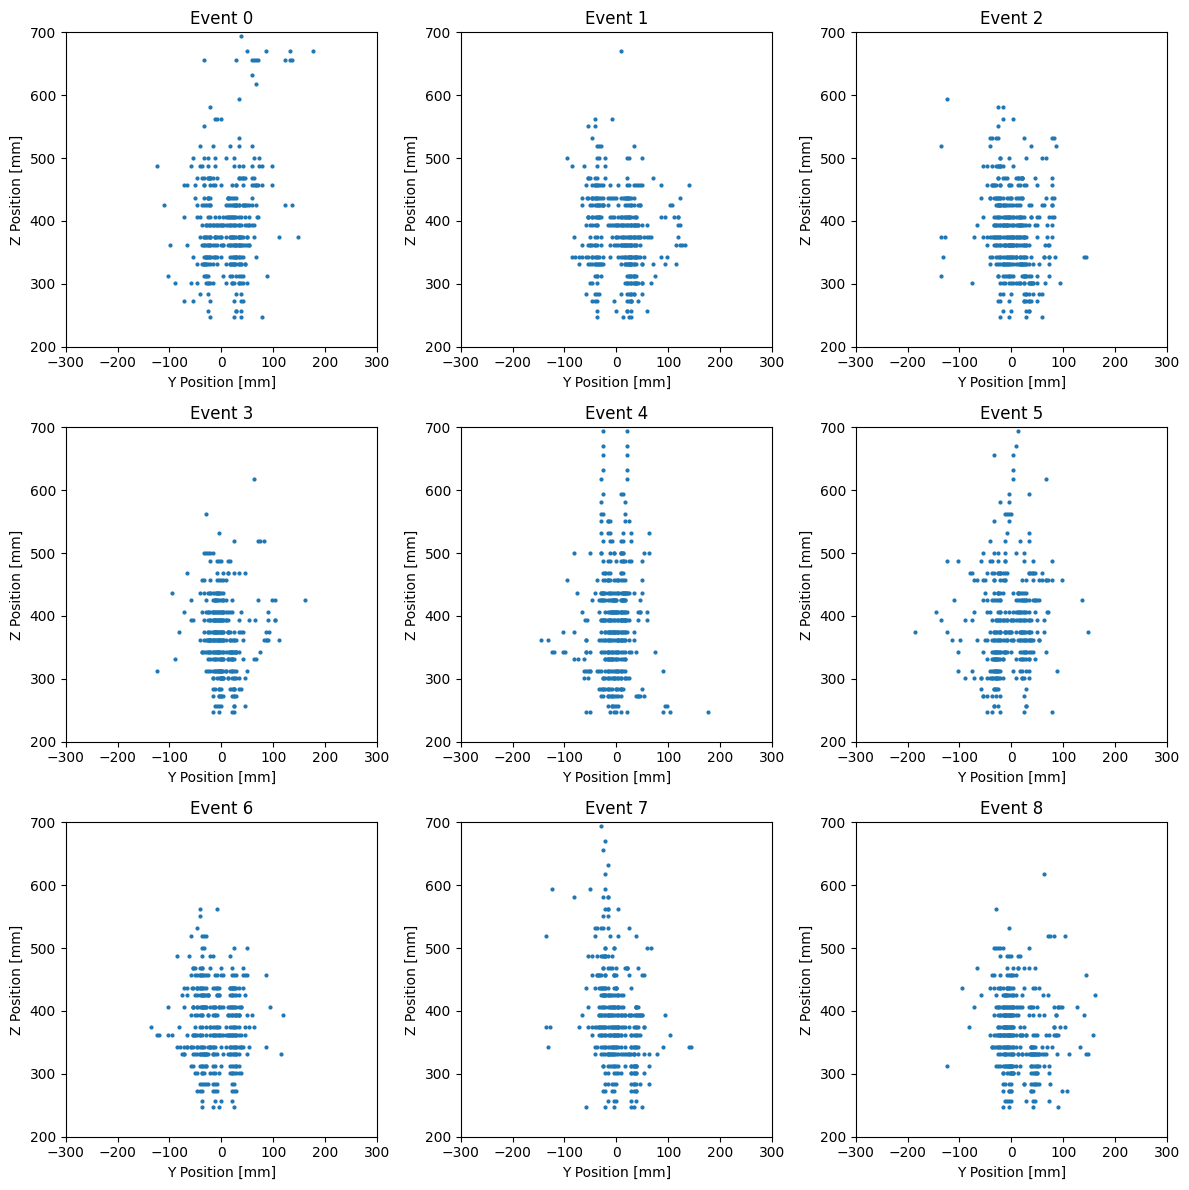

In [57]:
# Scatter plots of y vs z for up to first 9 events (3x3 grid)

rows, columns = 3, 3
nplots = rows * columns
nevents = len(ecal_y)
nshow = min(nplots, nevents)

fig, ax = plt.subplots(rows, columns, figsize=(12, 12))
ax = ax.flatten()

for index in range(nshow):
    ax[index].scatter(ecal_y[index], ecal_z[index], s=4)
    ax[index].set_title(f"Event {index}")
    ax[index].set_xlabel("Y Position [mm]")
    ax[index].set_ylabel("Z Position [mm]")
    ax[index].set_xlim(-300, 300)
    ax[index].set_ylim(200, 700)

# turn off unused panels
for index in range(nshow, nplots):
    ax[index].axis("off")

plt.tight_layout()
plt.savefig(f"{figures_path}ecal_y_z_hits_3x3.png", dpi=300)
plt.show()

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def make_category_codes(series):
    cats = pd.Categorical(series)
    return cats.codes, list(cats.categories)

def plot_simhits_2d(
    df,
    event_idx=0,
    xcol="z",
    ycol="x",
    color_mode="hit_edep",
    annotate=False,
    max_labels=40,
    figsize=(10, 6),
):
    plot_df = df.copy()

    fig, ax = plt.subplots(figsize=figsize)

    if color_mode == "hit_edep":
        sizes = 10 + 120 * plot_df["hit_edep"] / plot_df["hit_edep"].max()
        sc = ax.scatter(
            plot_df[xcol],
            plot_df[ycol],
            c=plot_df["hit_edep"],
            s=sizes,
            alpha=0.8,
        )
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Hit energy [MeV]")

    elif color_mode in ["dominant_track_id", "dominant_origin", "dominant_pdg", "is_mixed"]:
        vals = plot_df[color_mode].astype(str)
        codes, cats = make_category_codes(vals)
        sc = ax.scatter(
            plot_df[xcol],
            plot_df[ycol],
            c=codes,
            s=25,
            alpha=0.85,
        )
        cbar = plt.colorbar(sc, ax=ax)
        tick_locs = np.arange(len(cats))
        cbar.set_ticks(tick_locs)
        cbar.set_ticklabels(cats)
        cbar.set_label(color_mode)

    else:
        raise ValueError(f"Unknown color_mode: {color_mode}")

    ax.set_title(f"ECal {ecal_hit_label}, event {event_idx}, colored by {color_mode}")
    ax.set_xlabel(f"{xcol} [mm]")
    ax.set_ylabel(f"{ycol} [mm]")

    if xcol == "z":
        ax.set_xlim(200, 700)
    else:
        ax.set_xlim(-300, 300)

    if ycol in ["x", "y"]:
        ax.set_ylim(-300, 300)

    if annotate:
        ann_df = plot_df.nlargest(min(max_labels, len(plot_df)), "hit_edep")
        for _, row in ann_df.iterrows():
            if color_mode == "dominant_track_id":
                label = str(row["dominant_track_id"])
            elif color_mode == "dominant_origin":
                label = str(row["dominant_origin"])
            elif color_mode == "dominant_pdg":
                label = str(row["dominant_pdg"])
            else:
                label = str(row["hit_idx"])
            ax.text(row[xcol], row[ycol], label, fontsize=7)

    plt.tight_layout()
    plt.show()

### 3D plot

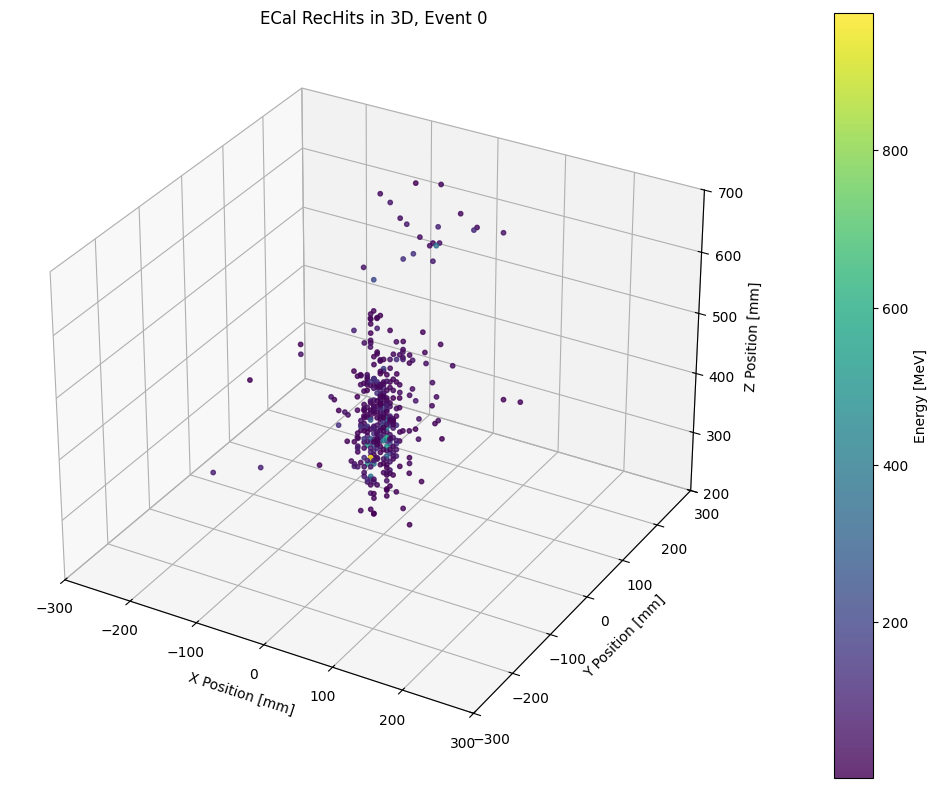

In [59]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
import awkward as ak
import matplotlib.pyplot as plt

event_idx = 0

# convert one event to regular numpy arrays
x = ak.to_numpy(ecal_x[event_idx])
y = ak.to_numpy(ecal_y[event_idx])
z = ak.to_numpy(ecal_z[event_idx])
e = ak.to_numpy(ecal_energy[event_idx])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(x, y, z, c=e, s=10, alpha=0.8)

ax.set_title(f"ECal {ecal_hit_label} in 3D, Event {event_idx}")
ax.set_xlabel("X Position [mm]")
ax.set_ylabel("Y Position [mm]")
ax.set_zlabel("Z Position [mm]")

ax.set_xlim(-300, 300)
ax.set_ylim(-300, 300)
ax.set_zlim(200, 700)

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Energy [MeV]")

plt.tight_layout()
plt.savefig(f"{figures_path}ecal_hits_3d_event0.png", dpi=300)
plt.show()

### Interactive 3D

In [60]:
import plotly.graph_objects as go

event_idx = 0

x = ak.to_numpy(ecal_x[event_idx])
y = ak.to_numpy(ecal_y[event_idx])
z = ak.to_numpy(ecal_z[event_idx])
e = ak.to_numpy(ecal_energy[event_idx])

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=x,
            y=y,
            z=z,
            mode="markers",
            marker=dict(
                size=3,
                color=e,
                colorscale="Viridis",
                colorbar=dict(title="Energy [MeV]"),
                opacity=0.8,
            ),
        )
    ]
)

fig.update_layout(
    title=f"ECal {ecal_hit_label} 3D (Event {event_idx})",
    scene=dict(
        xaxis_title="X [mm]",
        yaxis_title="Y [mm]",
        zaxis_title="Z [mm]",
        xaxis=dict(range=[-300, 300]),
        yaxis=dict(range=[-300, 300]),
        zaxis=dict(range=[200, 700]),
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()

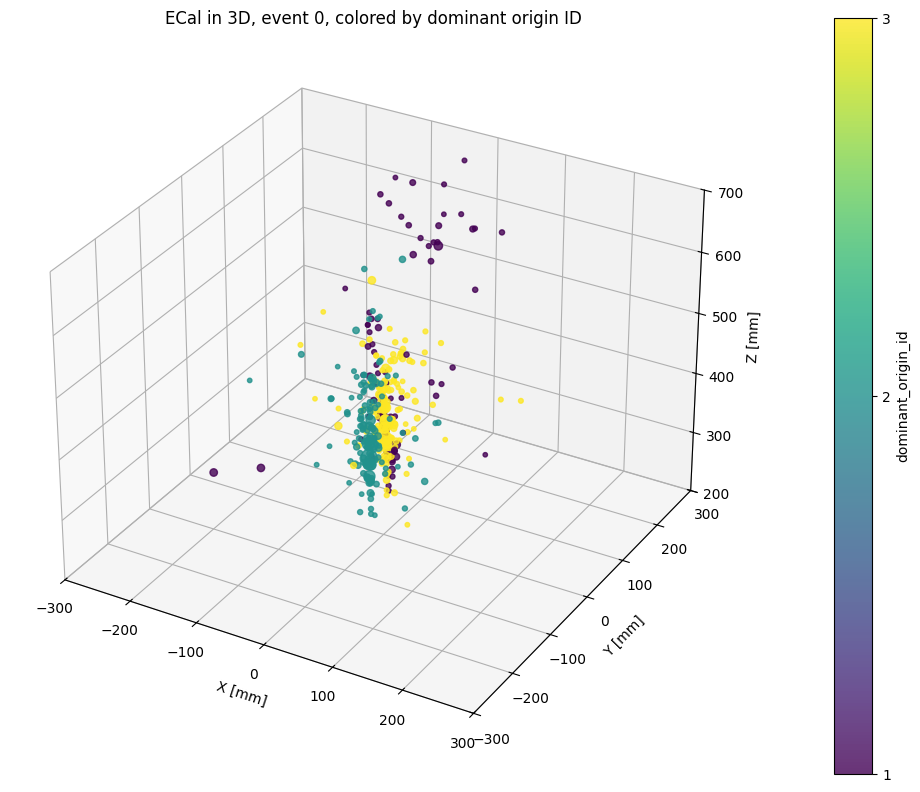

In [61]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
import matplotlib.pyplot as plt
import numpy as np

event_plot_df = hits_df.copy()

x = event_plot_df["x"].to_numpy()
y = event_plot_df["y"].to_numpy()
z = event_plot_df["z"].to_numpy()
e = event_plot_df["hit_edep"].to_numpy()
origin = event_plot_df["dominant_origin"].astype(str)

codes, cats = make_category_codes(origin)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    x, y, z,
    c=codes,
    s=10 + 120 * e / e.max(),
    alpha=0.8,
)

ax.set_title(f"ECal in 3D, event {event_idx}, colored by dominant origin ID")
ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_zlabel("Z [mm]")

ax.set_xlim(-300, 300)
ax.set_ylim(-300, 300)
ax.set_zlim(200, 700)

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
tick_locs = np.arange(len(cats))
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(cats)
cbar.set_label("dominant_origin_id")

plt.tight_layout()
plt.savefig(f"{figures_path}ecal_3d_origin_id_event0.png", dpi=300)
plt.show()

In [62]:
import pandas as pd
import plotly.express as px

event_plot_df = hits_df.copy()

def decode_dominant_track_id(encoded_id):
    if pd.isna(encoded_id) or int(encoded_id) < 0:
        return {
            "dominant_track_id_encoded": int(encoded_id) if not pd.isna(encoded_id) else pd.NA,
            "dominant_track_id_version": pd.NA,
            "dominant_track_id_event_index": pd.NA,
            "dominant_track_id_decoded": pd.NA,
        }

    decoded = decode_track_id(int(encoded_id))
    return {
        "dominant_track_id_encoded": decoded["raw"],
        "dominant_track_id_version": decoded["version"],
        "dominant_track_id_event_index": decoded["event_index"],
        "dominant_track_id_decoded": decoded["track_id"],
    }

decoded_track_ids = event_plot_df["dominant_track_id"].apply(decode_dominant_track_id).apply(pd.Series)
event_plot_df = event_plot_df.join(decoded_track_ids)

event_plot_df["track_str"] = event_plot_df["dominant_track_id"].astype(str)
event_plot_df["origin_str"] = event_plot_df["dominant_origin"].astype(str)
event_plot_df["pdg_str"] = event_plot_df["dominant_pdg"].astype(str)

fig = px.scatter_3d(
    event_plot_df,
    x="x",
    y="y",
    z="z",
    color="track_str",   # change to "origin_str" if you want
    size="hit_edep",
    hover_data={
        "hit_idx": True,
        "hit_id": True,
        "hit_edep": ':.3f',
        "dominant_track_id": False,
        "dominant_track_id_encoded": True,
        "dominant_track_id_decoded": True,
        "dominant_track_id_version": True,
        "dominant_track_id_event_index": True,
        "dominant_origin": True,
        "dominant_pdg": True,
        "dominant_frac": ':.3f',
        "n_contribs": True,
        "is_mixed": True,
        "all_track_ids": True,
        "all_origins": True,
        "x": ':.2f',
        "y": ':.2f',
        "z": ':.2f',
    },
    labels={
        "track_str": "dominant track ID encoded",
        "dominant_track_id_encoded": "dominant track ID encoded",
        "dominant_track_id_decoded": "dominant track ID decoded track_id",
        "dominant_track_id_version": "dominant track ID decoded version",
        "dominant_track_id_event_index": "dominant track ID decoded event_index",
    },
    title=f"ECal 3D, event {event_idx}, colored by dominant track ID",
)

fig.update_layout(
    scene=dict(
        xaxis_title="X [mm]",
        yaxis_title="Y [mm]",
        zaxis_title="Z [mm]",
        xaxis=dict(range=[-300, 300]),
        yaxis=dict(range=[-300, 300]),
        zaxis=dict(range=[200, 700]),
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()